# Customer Churn Analysis — Affinity-Weighted Pattern Matching

This notebook extends the baseline churn analysis by enabling **affinity-weighted pattern matching with symbol emotive bias**. During training, KATO unconditionally accumulates per-symbol affinity values from the `utility` emotive. Before predictions, we activate `affinity_emotive="utility"` so that similarity calculations weight symbols by their cumulative emotive charge — amplifying signal tokens and discounting noise.

**Hypothesis:** Affinity-weighted metrics may (1) improve prediction accuracy over unweighted baselines, and (2) make ensemble predictions (`max_predictions > 1`) viable, since noise tokens that diluted ensemble signal are now down-weighted.

**Sweep:** Only the 4 weighted ranking algorithms are tested (`weighted_similarity`, `weighted_evidence`, `weighted_confidence`, `weighted_snr`) with `max_predictions ∈ {1, 5, 10, 30}`.

In [1]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import json
import math
import time
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
%matplotlib inline

## Configuration

**Fixed parameters** (not swept): `PROBABILITY_METHOD`, `TEMPERATURE`, `CLASSIFICATION_THRESHOLD`

**Swept parameters** (weighted-only grid):
1. **RANK_SORT_ALGO** — affinity-weighted ranking (4 options: `weighted_similarity`, `weighted_evidence`, `weighted_confidence`, `weighted_snr`)
2. **RECALL_THRESHOLD** — pattern matching strictness (3 options)
3. **MAX_PREDICTIONS** — ensemble size (4 options, including new `5`)
4. **WEIGHTING_METRIC** — client-side aggregation weight (4 weighted options)

In [2]:
# === KATO Connection ===
KATO_URL = "http://kato:8000"  # Docker containers on kato_kato-network
# KATO_URL = "http://localhost:8000"  # Host machine access

# === Dataset ===
TRAIN_FRACTION = 0.8    # Fraction of data for training
TEST_FRACTION = 0.2     # Fraction of data for testing (drawn from remaining samples)

# === Default KATO Prediction Parameters ===
RANK_SORT_ALGO = "weighted_similarity"
RECALL_THRESHOLD = 0.2
MAX_PREDICTIONS = 10

# === Default Ensemble Weighting ===
WEIGHTING_METRIC = "weighted_similarity"
PROBABILITY_METHOD = "linear"  # FIXED during sweep
TEMPERATURE = 25.0              # FIXED during sweep
CLASSIFICATION_THRESHOLD = 0.5  # FIXED during sweep

# === Parameter Sweep Grid (weighted metrics only) ===
RANK_SORT_OPTIONS = [
    'weighted_similarity', 'weighted_evidence',
    'weighted_confidence', 'weighted_snr',
]
RECALL_THRESHOLD_OPTIONS = [0.1, 0.4, 0.6]
MAX_PREDICTIONS_OPTIONS = [1, 5, 10, 30]
WEIGHTING_METRIC_OPTIONS = [
    'weighted_similarity', 'weighted_evidence',
    'weighted_confidence', 'weighted_snr',
]

n_server = len(RANK_SORT_OPTIONS) * len(RECALL_THRESHOLD_OPTIONS) * len(MAX_PREDICTIONS_OPTIONS)
n_total = n_server * len(WEIGHTING_METRIC_OPTIONS)
print(f"Server-side configs: {n_server}")
print(f"Total combos (x weighting metrics): {n_total}")

Server-side configs: 48
Total combos (x weighting metrics): 192


In [3]:
# HTTP session with automatic retry for transient connection errors
http = requests.Session()
retries = Retry(total=3, connect=3, backoff_factor=1.0, allowed_methods=["GET", "POST"])
http.mount("http://", HTTPAdapter(max_retries=retries))
http.mount("https://", HTTPAdapter(max_retries=retries))

def check_kato_health():
    """Check if KATO server is running and healthy"""
    try:
        response = http.get(f"{KATO_URL}/health", timeout=5)
        if response.status_code == 200:
            health_data = response.json()
            print("✅ KATO is healthy!")
            print(f"   Status: {health_data.get('status')}")
            print(f"   Service: {health_data.get('service_name', 'KATO')}")
            if 'uptime_seconds' in health_data:
                print(f"   Uptime: {health_data['uptime_seconds']} seconds")
            return True
        else:
            print(f"❌ KATO health check failed: {response.status_code}")
            return False
    except requests.exceptions.ConnectionError:
        print("❌ Cannot connect to KATO.")
        print("   Troubleshooting:")
        print("   1. Make sure Docker containers are running: docker-compose up -d")
        print("   2. If using 'kato' hostname, ensure Jupyter is on kato_kato-network")
        print("   3. Try changing KATO_URL to 'http://localhost:8000' if running on host")
        return False
    except Exception as e:
        print(f"❌ Error checking KATO health: {e}")
        return False

def verify_network_connectivity():
    """Verify Docker network connectivity"""
    try:
        import socket
        socket.gethostbyname('kato')
        print("✅ Network connectivity: Can resolve 'kato' hostname")
        return True
    except socket.gaierror:
        print("❌ Network connectivity: Cannot resolve 'kato' hostname")
        print("   Either:")
        print("   1. Start Jupyter with --network kato_kato-network")
        print("   2. Change KATO_URL to use 'localhost' instead of 'kato'")
        return False

print("🔍 Checking network connectivity...")
verify_network_connectivity()
print("\n🏥 Checking KATO health...")
check_kato_health()

🔍 Checking network connectivity...
✅ Network connectivity: Can resolve 'kato' hostname

🏥 Checking KATO health...
✅ KATO is healthy!
   Status: healthy
   Service: kato
   Uptime: 240326.0239841938 seconds


True

In [4]:
def create_session(name, max_pattern_length=0, recall_threshold=0.1, node_id=None, affinity_emotive=None):
    """Create a new KATO session with specified configuration"""
    if node_id is None:
        import uuid
        node_id = f"churn_node_{uuid.uuid4().hex[:8]}"

    session_config = {
        "node_id": node_id,
        "config": {
            "max_pattern_length": max_pattern_length,
            "recall_threshold": recall_threshold
        },
        "ttl_seconds": 3600,
        "metadata": {"name": name}
    }
    if affinity_emotive:
        session_config["config"]["affinity_emotive"] = affinity_emotive

    response = http.post(f"{KATO_URL}/sessions", json=session_config)
    if response.status_code == 200:
        session_data = response.json()
        session_id = session_data['session_id']
        print(f"✅ Created session: {name}")
        print(f"   Session ID: {session_id}")
        print(f"   Node ID: {session_data['node_id']}")
        print(f"   Recall threshold: {recall_threshold}")
        if affinity_emotive:
            print(f"   Affinity emotive: {affinity_emotive}")
        return session_id
    else:
        print(f"❌ Failed to create session: {response.status_code}")
        print(response.text)
        return None

def clear_all_memory(session_id):
    """Clear ALL memory (STM and learned patterns) for a session."""
    response = http.post(f"{KATO_URL}/sessions/{session_id}/clear-all", json={})
    if response.status_code == 200:
        print("🧹 Cleared all memory")
        return True
    else:
        print(f"❌ Failed to clear all memory: {response.status_code}")
        return False

def update_session_config(session_id, config):
    """Update session configuration parameters."""
    response = http.post(
        f"{KATO_URL}/sessions/{session_id}/config",
        json={"config": config}
    )
    if response.status_code == 200:
        print(f"✅ Updated config: {config}")
        return True
    else:
        print(f"❌ Failed to update config: {response.status_code}")
        print(response.json())
        return False

## Data Loading & Exploration

In [5]:
churn_df = pd.read_csv('data/churn.csv')
print(f"Dataset: {churn_df.shape[0]} rows, {churn_df.shape[1]} columns")
print(f"\nChurn distribution:")
print(churn_df['Churn?'].value_counts())
print(f"\nChurn rate: {(churn_df['Churn?'] == 'True.').mean():.1%}")
print(f"\nSample rows:")
churn_df.head(3)

Dataset: 3333 rows, 21 columns

Churn distribution:
Churn?
False.    2850
True.      483
Name: count, dtype: int64

Churn rate: 14.5%

Sample rows:


,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.


In [6]:
# Prepare train/test split — non-overlapping samples
feature_columns = [c for c in churn_df.columns if c not in ['Phone', 'Churn?']]
print(f"Features ({len(feature_columns)}): {feature_columns[:5]}...")

train_size = int(len(churn_df) * TRAIN_FRACTION)
test_size = int(len(churn_df) * TEST_FRACTION)

# Training takes the first train_size rows, testing takes the next test_size rows
# This guarantees no overlap between training and testing sets
assert train_size + test_size <= len(churn_df), \
    f"TRAIN_FRACTION ({TRAIN_FRACTION}) + TEST_FRACTION ({TEST_FRACTION}) exceeds dataset size"

churn_train = churn_df[:train_size].to_dict('records')
churn_test = churn_df[train_size:train_size + test_size].to_dict('records')
print(f"Training: {len(churn_train)} samples ({TRAIN_FRACTION:.0%})")
print(f"Testing:  {len(churn_test)} samples ({TEST_FRACTION:.0%})")
print(f"Unused:   {len(churn_df) - train_size - test_size} samples")

Features (19): ['State', 'Account Length', 'Area Code', "Int'l Plan", 'VMail Plan']...
Training: 2666 samples (80%)
Testing:  666 samples (20%)
Unused:   1 samples


## Connect to KATO

In [7]:
# Create session (without affinity_emotive — affinity accumulates unconditionally during learning)
session_id = create_session("Churn Ensemble (Affinity-Weighted)", node_id="churn_ensemble", recall_threshold=RECALL_THRESHOLD)

✅ Created session: Churn Ensemble (Affinity-Weighted)
   Session ID: session-7baf2c01df534216a2b80711111bd39a-1776004206417
   Node ID: churn_ensemble
   Recall threshold: 0.2


## Training
### Note: If you've already trained using the churn_analysis.ipynb notebook (or any other way), then you don't need to re-train. Just jump to Enable Affinity-Weighted Matching. 

Train KATO with two-event sequences per customer:
1. **Features** — pipe-delimited strings (`"State|CA"`, `"Account Length|120"`, ...)
2. **Outcome** — utility polarity emotive (`-100` = churned, `+100` = stayed)

**Note:** Symbol affinity accumulates unconditionally during learning whenever emotives are present. We do NOT need `affinity_emotive` set for training — it only needs to be activated before predictions.

In [8]:
clear_all_memory(session_id)

# Disable predictions during training for performance
update_session_config(session_id, {"process_predictions": False})

print("\n🎓 Training on customer churn data...")
for idx, row in enumerate(churn_train):
    http.post(f"{KATO_URL}/sessions/{session_id}/clear-stm", json={})

    # Event 1: Customer features as pipe-delimited strings
    profile_strings = [f"{key}|{value}" for key, value in row.items() if key in feature_columns]
    http.post(f"{KATO_URL}/sessions/{session_id}/observe",
              json={"strings": profile_strings, "vectors": [], "emotives": {}})

    # Event 2: Churn outcome as utility polarity
    utility = -100 if row['Churn?'] == 'True.' else 100
    http.post(f"{KATO_URL}/sessions/{session_id}/observe",
              json={"strings": [], "vectors": [], "emotives": {"utility": float(utility)}})

    http.post(f"{KATO_URL}/sessions/{session_id}/learn", json={})
    if (idx + 1) % 50 == 0:
        print(f"  Trained {idx + 1}/{len(churn_train)} samples...")

print(f"✅ Trained on {len(churn_train)} customer profiles")

# Finalize training: pre-compute entropy and TF vectors across all learned patterns.
# These metrics depend on corpus-level statistics that are only stable after training completes.
response = http.post(f"{KATO_URL}/sessions/{session_id}/finalize-training", json={})
if response.status_code == 200:
    print("✅ Finalized training (pre-computed entropy & TF metrics)")
else:
    print(f"⚠️ Finalize training returned {response.status_code} — predictions will use on-the-fly fallback")

🧹 Cleared all memory
✅ Updated config: {'process_predictions': False}

🎓 Training on customer churn data...
  Trained 50/2666 samples...
  Trained 100/2666 samples...
  Trained 150/2666 samples...
  Trained 200/2666 samples...
  Trained 250/2666 samples...
  Trained 300/2666 samples...
  Trained 350/2666 samples...
  Trained 400/2666 samples...
  Trained 450/2666 samples...
  Trained 500/2666 samples...
  Trained 550/2666 samples...
  Trained 600/2666 samples...
  Trained 650/2666 samples...
  Trained 700/2666 samples...
  Trained 750/2666 samples...
  Trained 800/2666 samples...
  Trained 850/2666 samples...
  Trained 900/2666 samples...
  Trained 950/2666 samples...
  Trained 1000/2666 samples...
  Trained 1050/2666 samples...
  Trained 1100/2666 samples...
  Trained 1150/2666 samples...
  Trained 1200/2666 samples...
  Trained 1250/2666 samples...
  Trained 1300/2666 samples...
  Trained 1350/2666 samples...
  Trained 1400/2666 samples...
  Trained 1450/2666 samples...
  Trained 150

## Enable Affinity-Weighted Matching

Now that training is complete and symbol affinities have been accumulated, we activate `affinity_emotive="utility"` so predictions use affinity-weighted similarity calculations.

**Weight formula:** `w(symbol) = |affinity(symbol, "utility")| / frequency(symbol) + epsilon`

Symbols with strong utility affinity (high |value| relative to frequency) get amplified; noise symbols (high frequency, near-zero affinity) get discounted to `epsilon = 0.01`.

In [9]:
# Activate affinity-weighted pattern matching for predictions
update_session_config(session_id, {"affinity_emotive": "utility"})

# Verify affinity data was accumulated during training
affinity_resp = http.get(f"{KATO_URL}/symbols/affinity", headers={'X-Node-ID': 'churn_ensemble'})
affinity_resp.raise_for_status()
affinities = affinity_resp.json()['affinities']
print(f"\nSymbols with affinity data: {len(affinities)}")

# Show a few sample symbols and their utility affinity
sample_symbols = sorted(affinities.items(), key=lambda x: abs(x[1].get('utility', 0)), reverse=True)[:5]
print("\nTop 5 symbols by |utility affinity|:")
for sym, aff in sample_symbols:
    print(f"  {sym}: utility={aff.get('utility', 0.0):+.1f}")

✅ Updated config: {'affinity_emotive': 'utility'}

Symbols with affinity data: 9059

Top 5 symbols by |utility affinity|:
  Int'l Plan|no: utility=+187700.0
  VMail Plan|no: utility=+131000.0
  VMail Message|0: utility=+131000.0
  Area Code|415: utility=+95300.0
  CustServ Calls|1: utility=+74700.0


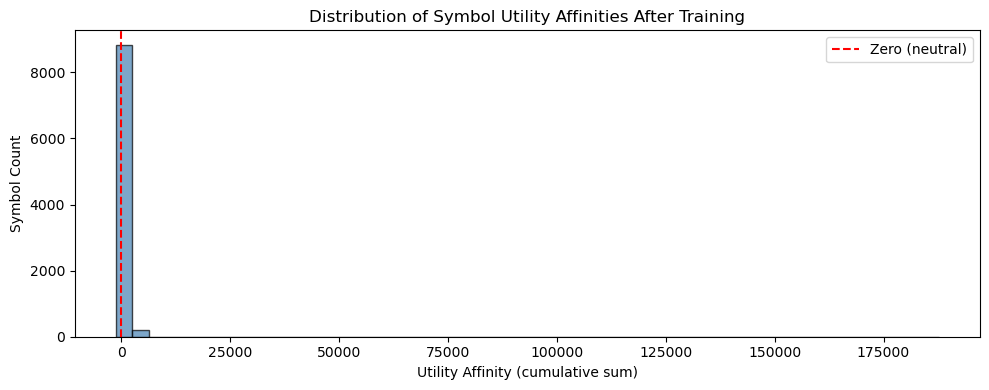

Positive affinity (retention signal): 7740 symbols
Negative affinity (churn signal):     736 symbols
Zero affinity (no emotive context):   583 symbols


In [10]:
# Visualize the distribution of utility affinity across all symbols
aff_values = [v.get('utility', 0.0) for v in affinities.values()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(aff_values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero (neutral)')
ax.set_xlabel('Utility Affinity (cumulative sum)')
ax.set_ylabel('Symbol Count')
ax.set_title('Distribution of Symbol Utility Affinities After Training')
ax.legend()
plt.tight_layout()
plt.show()

positive = sum(1 for v in aff_values if v > 0)
negative = sum(1 for v in aff_values if v < 0)
zero = sum(1 for v in aff_values if v == 0)
print(f"Positive affinity (retention signal): {positive} symbols")
print(f"Negative affinity (churn signal):     {negative} symbols")
print(f"Zero affinity (no emotive context):   {zero} symbols")

## Ensemble Prediction Logic

Instead of using only the top prediction, we weight **all predictions** in the ensemble:

1. For each prediction `p`, extract its `utility` emotive and its weight from the chosen `WEIGHTING_METRIC`
2. Compute the **weighted average utility**: `sum(w_i * u_i) / sum(w_i)`
3. Map to a **churn probability** using either:
   - **Sigmoid** (default): `P(churn) = 1 / (1 + exp(weighted_utility / temperature))` — smooth, tunable steepness
   - **Linear**: `P(churn) = (1 - weighted_utility / 100) / 2` — simple direct mapping
4. Classify: `P(churn) > threshold` → churn

**Key distinction**: `RANK_SORT_ALGO` controls which predictions KATO returns (server-side). `WEIGHTING_METRIC` controls how we combine them (client-side). These can be tuned independently.

In [11]:
def compute_churn_probability(predictions, weighting_metric=WEIGHTING_METRIC,
                               method=PROBABILITY_METHOD, temperature=TEMPERATURE):
    """Compute churn probability from a KATO prediction ensemble.

    Args:
        predictions: Raw response from /predictions endpoint
        weighting_metric: Which prediction metric to use as weight
        method: "sigmoid" or "linear"
        temperature: Sigmoid steepness (only used if method="sigmoid")

    Returns:
        (churn_prob, weighted_utility, n_preds_used)
    """
    preds = predictions.get('predictions', [])
    if not preds:
        return 0.5, 0.0, 0  # No predictions = maximum uncertainty

    weights = []
    utilities = []
    for p in preds:
        u = p.get('emotives', {}).get('utility')
        w = p.get(weighting_metric) or 0
        if u is not None and w > 0:
            weights.append(w)
            utilities.append(u)

    if not weights:
        return 0.5, 0.0, 0

    total_weight = sum(weights)
    weighted_utility = sum(w * u for w, u in zip(weights, utilities)) / total_weight

    if method == "sigmoid":
        churn_prob = 1 / (1 + math.exp(weighted_utility / temperature))
    else:  # linear
        churn_prob = (1 - weighted_utility / 100) / 2
        churn_prob = max(0.0, min(1.0, churn_prob))

    return churn_prob, weighted_utility, len(weights)


def classify_churn(churn_prob, threshold=CLASSIFICATION_THRESHOLD):
    """Binary classification from probability."""
    return "churn" if churn_prob > threshold else "stay"

## Parameter Sweep (Weighted Metrics Only)

For each test sample we **observe features once**, then re-query KATO predictions across all 48 server-side configurations (4 weighted RANK_SORT_ALGO x 3 RECALL_THRESHOLD x 4 MAX_PREDICTIONS). STM persists across config changes, so each observe is done only once per sample.

For each server response, we also sweep all 4 weighted WEIGHTING_METRIC options client-side (instant, no re-querying). This gives **192 total parameter combinations** evaluated.

**Key difference from baseline:** `affinity_emotive="utility"` is active, so predictions include `weighted_similarity`, `weighted_evidence`, `weighted_confidence`, and `weighted_snr` fields.

In [12]:
# Build the full grid of server-side configs
from itertools import product

server_configs = list(product(RANK_SORT_OPTIONS, RECALL_THRESHOLD_OPTIONS, MAX_PREDICTIONS_OPTIONS))
print(f"Server-side configs to evaluate: {len(server_configs)}")
print(f"Test samples: {len(churn_test)}")
print(f"Total prediction queries: {len(server_configs) * len(churn_test):,}")

actuals = ["churn" if row['Churn?'] == 'True.' else "stay" for row in churn_test]

Server-side configs to evaluate: 48
Test samples: 666
Total prediction queries: 31,968


In [13]:
# Parameter sweep: observe once per sample, query all server configs
# STM persists across config changes — predictions are read-only
import time

# all_classifications[(algo, rt, mp, wm)] = list of 666 predicted labels
all_classifications = {}

t_start = time.time()
for sample_idx, row in enumerate(churn_test):
    # Observe features ONCE per sample
    http.post(f"{KATO_URL}/sessions/{session_id}/clear-stm", json={})
    profile_strings = [f"{key}|{value}" for key, value in row.items() if key in feature_columns]
    http.post(f"{KATO_URL}/sessions/{session_id}/observe",
              json={"strings": profile_strings, "vectors": [], "emotives": {}})

    # Query all 63 server configs with the same STM
    for algo, rt, mp in server_configs:
        http.post(f"{KATO_URL}/sessions/{session_id}/config",
                  json={"config": {
                      "process_predictions": True,
                      "rank_sort_algo": algo,
                      "max_predictions": mp,
                      "recall_threshold": rt
                  }})
        response = http.get(f"{KATO_URL}/sessions/{session_id}/predictions")
        preds = response.json() if response.status_code == 200 else {"predictions": []}

        # Sweep all weighting metrics client-side (instant)
        for wm in WEIGHTING_METRIC_OPTIONS:
            prob, _, _ = compute_churn_probability(
                preds, weighting_metric=wm,
                method=PROBABILITY_METHOD, temperature=TEMPERATURE)
            label = classify_churn(prob, threshold=CLASSIFICATION_THRESHOLD)
            key = (algo, rt, mp, wm)
            if key not in all_classifications:
                all_classifications[key] = []
            all_classifications[key].append(label)

    if (sample_idx + 1) % 20 == 0 or sample_idx == 0:
        elapsed = time.time() - t_start
        rate = (sample_idx + 1) / elapsed
        remaining = (len(churn_test) - sample_idx - 1) / rate
        print(f"  Sample {sample_idx + 1}/{len(churn_test)} "
              f"({elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining)")

elapsed_total = time.time() - t_start
print(f"\nSweep complete: {len(all_classifications)} combos, {elapsed_total:.0f}s total")

  Sample 1/666 (18s elapsed, ~11771s remaining)
  Sample 20/666 (432s elapsed, ~13944s remaining)
  Sample 40/666 (871s elapsed, ~13636s remaining)
  Sample 60/666 (1309s elapsed, ~13225s remaining)
  Sample 80/666 (1739s elapsed, ~12739s remaining)
  Sample 100/666 (2185s elapsed, ~12366s remaining)
  Sample 120/666 (2617s elapsed, ~11906s remaining)
  Sample 140/666 (3059s elapsed, ~11492s remaining)
  Sample 160/666 (3506s elapsed, ~11089s remaining)
  Sample 180/666 (3963s elapsed, ~10700s remaining)
  Sample 200/666 (4387s elapsed, ~10221s remaining)
  Sample 220/666 (4810s elapsed, ~9752s remaining)
  Sample 240/666 (5226s elapsed, ~9277s remaining)
  Sample 260/666 (5667s elapsed, ~8849s remaining)
  Sample 280/666 (6094s elapsed, ~8401s remaining)
  Sample 300/666 (6516s elapsed, ~7950s remaining)
  Sample 320/666 (6938s elapsed, ~7502s remaining)
  Sample 340/666 (7357s elapsed, ~7054s remaining)
  Sample 360/666 (7778s elapsed, ~6611s remaining)
  Sample 380/666 (8205s elapse

## Evaluation — All 192 Configurations

Compute POC alpha (positive and negative) for every parameter combination and rank by combined alpha.

In [14]:
from poc_chart import compute_predictor_metrics

rows = []
for (algo, rt, mp, wm), predicted in all_classifications.items():
    pos_m = compute_predictor_metrics(
        name="", predicted_labels=predicted, true_labels=actuals,
        num_classes=2, mode="positive", positive_classes={"stay"})
    neg_m = compute_predictor_metrics(
        name="", predicted_labels=predicted, true_labels=actuals,
        num_classes=2, mode="negative", positive_classes={"stay"})
    rows.append({
        "rank_sort_algo": algo,
        "recall_threshold": rt,
        "max_predictions": mp,
        "weighting_metric": wm,
        "pos_alpha": pos_m.alpha,
        "neg_alpha": neg_m.alpha,
        "pos_precision": pos_m.precision,
        "neg_precision": neg_m.precision,
        "pos_accuracy": pos_m.accuracy,
        "neg_accuracy": neg_m.accuracy,
    })

eval_df = pd.DataFrame(rows)
eval_df["combined_alpha"] = (eval_df["pos_alpha"] + eval_df["neg_alpha"]) / 2
eval_df = eval_df.sort_values("combined_alpha", ascending=False).reset_index(drop=True)

# Assign alphanumeric labels to top configs
eval_df["label"] = [f"P{i+1:02d}" if i < 99 else f"P{i+1}" for i in range(len(eval_df))]

print(f"Evaluated {len(eval_df)} parameter combinations\n")

print("=" * 90)
print("Top 10 by Combined Alpha (avg of positive + negative)")
print("=" * 90)
cols = ["label", "rank_sort_algo", "recall_threshold", "max_predictions",
        "weighting_metric", "pos_alpha", "neg_alpha", "combined_alpha"]
print(eval_df.head(10)[cols].to_string(index=False, float_format="{:.4f}".format))

print(f"\n{'=' * 90}")
print("Top 10 by Positive Alpha (stay classification)")
print("=" * 90)
top_pos = eval_df.nlargest(10, "pos_alpha")
print(top_pos[cols].to_string(index=False, float_format="{:.4f}".format))

print(f"\n{'=' * 90}")
print("Top 10 by Negative Alpha (churn classification)")
print("=" * 90)
top_neg = eval_df.nlargest(10, "neg_alpha")
print(top_neg[cols].to_string(index=False, float_format="{:.4f}".format))

Evaluated 192 parameter combinations

Top 10 by Combined Alpha (avg of positive + negative)
label      rank_sort_algo  recall_threshold  max_predictions    weighting_metric  pos_alpha  neg_alpha  combined_alpha
  P01 weighted_similarity            0.1000                5        weighted_snr     0.0061     0.0586          0.0323
  P02   weighted_evidence            0.1000                5        weighted_snr     0.0047     0.0460          0.0254
  P03 weighted_confidence            0.1000                5        weighted_snr     0.0051     0.0453          0.0252
  P04 weighted_similarity            0.1000                5   weighted_evidence     0.0048     0.0422          0.0235
  P05 weighted_similarity            0.1000                5 weighted_confidence     0.0048     0.0422          0.0235
  P06 weighted_confidence            0.1000                1 weighted_confidence     0.0115     0.0329          0.0222
  P07 weighted_confidence            0.1000                1        weighte

Best config: P01
  rank_sort_algo:  weighted_similarity
  recall_threshold: 0.1
  max_predictions:  5
  weighting_metric: weighted_snr
  pos_alpha: +0.0061
  neg_alpha: +0.0586
  combined:  +0.0323

Accuracy: 78.4%

              precision    recall  f1-score   support

       churn       0.22      0.13      0.16       109
        stay       0.84      0.91      0.88       557

    accuracy                           0.78       666
   macro avg       0.53      0.52      0.52       666
weighted avg       0.74      0.78      0.76       666



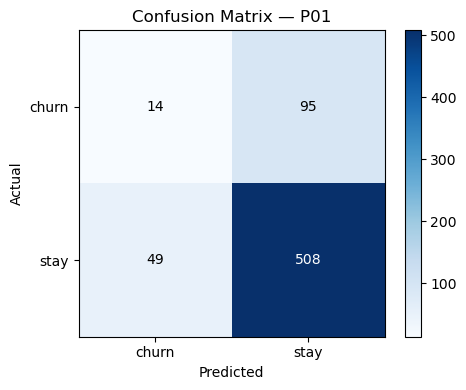

In [15]:
# Confusion matrix for the best config (P01)
best = eval_df.iloc[0]
best_key = (best["rank_sort_algo"], best["recall_threshold"],
            best["max_predictions"], best["weighting_metric"])
best_predicted = all_classifications[best_key]

print(f"Best config: {best['label']}")
print(f"  rank_sort_algo:  {best['rank_sort_algo']}")
print(f"  recall_threshold: {best['recall_threshold']}")
print(f"  max_predictions:  {int(best['max_predictions'])}")
print(f"  weighting_metric: {best['weighting_metric']}")
print(f"  pos_alpha: {best['pos_alpha']:+.4f}")
print(f"  neg_alpha: {best['neg_alpha']:+.4f}")
print(f"  combined:  {best['combined_alpha']:+.4f}")

ensemble_acc = accuracy_score(actuals, best_predicted)
print(f"\nAccuracy: {ensemble_acc:.1%}")
print(f"\n{classification_report(actuals, best_predicted)}")

cm = confusion_matrix(actuals, best_predicted, labels=['churn', 'stay'])
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['churn', 'stay'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['churn', 'stay'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best["label"]}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

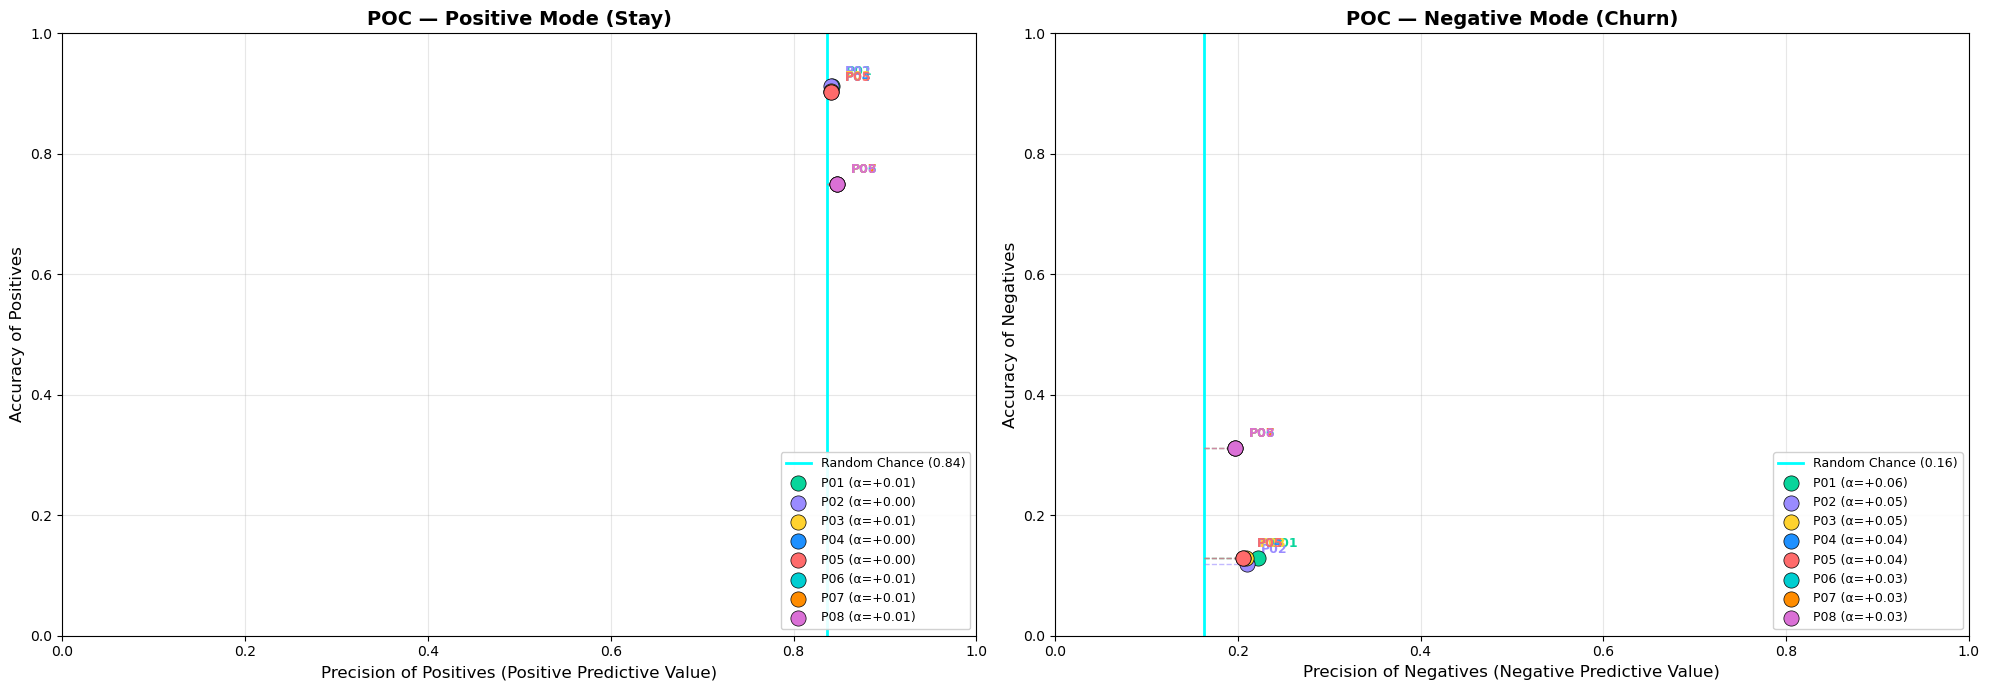


Configuration Reference (Top 8 by combined alpha):
label      rank_sort_algo  recall_threshold  max_predictions    weighting_metric  pos_alpha  neg_alpha  combined_alpha
  P01 weighted_similarity            0.1000                5        weighted_snr     0.0061     0.0586          0.0323
  P02   weighted_evidence            0.1000                5        weighted_snr     0.0047     0.0460          0.0254
  P03 weighted_confidence            0.1000                5        weighted_snr     0.0051     0.0453          0.0252
  P04 weighted_similarity            0.1000                5   weighted_evidence     0.0048     0.0422          0.0235
  P05 weighted_similarity            0.1000                5 weighted_confidence     0.0048     0.0422          0.0235
  P06 weighted_confidence            0.1000                1 weighted_confidence     0.0115     0.0329          0.0222
  P07 weighted_confidence            0.1000                1        weighted_snr     0.0115     0.0329          0.0

In [16]:
# POC charts with top configurations
from poc_chart import poc_chart

TOP_N = 8
top_configs = eval_df.head(TOP_N)

# Build dict-form inputs for poc_chart
pred_dict_pos = {}
actual_dict_pos = {}
pred_dict_neg = {}
actual_dict_neg = {}

for _, cfg_row in top_configs.iterrows():
    lbl = cfg_row["label"]
    key = (cfg_row["rank_sort_algo"], cfg_row["recall_threshold"],
           cfg_row["max_predictions"], cfg_row["weighting_metric"])
    predicted = all_classifications[key]
    pred_dict_pos[lbl] = predicted
    actual_dict_pos[lbl] = actuals
    pred_dict_neg[lbl] = predicted
    actual_dict_neg[lbl] = actuals

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

poc_chart(pred_dict_pos, actual_dict_pos, num_classes=2,
          mode="positive", positive_classes={"stay"}, ax=ax1,
          title="POC — Positive Mode (Stay)")
poc_chart(pred_dict_neg, actual_dict_neg, num_classes=2,
          mode="negative", positive_classes={"stay"}, ax=ax2,
          title="POC — Negative Mode (Churn)")

plt.tight_layout()
plt.show()

# Reference table
print(f"\nConfiguration Reference (Top {TOP_N} by combined alpha):")
print("=" * 100)
ref_cols = ["label", "rank_sort_algo", "recall_threshold", "max_predictions",
            "weighting_metric", "pos_alpha", "neg_alpha", "combined_alpha"]
print(top_configs[ref_cols].to_string(index=False, float_format="{:.4f}".format))

## Ensemble Viability Analysis

The baseline churn analysis found that `max_predictions=1` always dominated — ensembles hurt performance. Does affinity weighting change this by down-weighting noise tokens in the similarity calculation?

In [17]:
# Ensemble viability: compare best single-prediction vs best ensemble
single_df = eval_df[eval_df['max_predictions'] == 1]
ensemble_df = eval_df[eval_df['max_predictions'] > 1]

best_single = single_df.iloc[0] if len(single_df) > 0 else None
best_ensemble = ensemble_df.iloc[0] if len(ensemble_df) > 0 else None

print("=" * 70)
print("ENSEMBLE VIABILITY — Does affinity weighting rescue ensembles?")
print("=" * 70)

if best_single is not None:
    print(f"\nBest single prediction (mp=1):")
    print(f"  Config: {best_single['rank_sort_algo']}, rt={best_single['recall_threshold']}, wm={best_single['weighting_metric']}")
    print(f"  Combined alpha: {best_single['combined_alpha']:.4f}")

if best_ensemble is not None:
    print(f"\nBest ensemble (mp>1):")
    print(f"  Config: {best_ensemble['rank_sort_algo']}, rt={best_ensemble['recall_threshold']}, "
          f"mp={int(best_ensemble['max_predictions'])}, wm={best_ensemble['weighting_metric']}")
    print(f"  Combined alpha: {best_ensemble['combined_alpha']:.4f}")

if best_single is not None and best_ensemble is not None:
    gap = best_ensemble['combined_alpha'] - best_single['combined_alpha']
    print(f"\nEnsemble gap: {gap:+.4f}")
    if gap > 0:
        print(">>> Affinity weighting DOES make ensembles competitive!")
    else:
        print(">>> Ensembles still underperform single predictions.")

# Breakdown by max_predictions
print(f"\n{'=' * 70}")
print("Best combined_alpha by max_predictions:")
print("=" * 70)
for mp in sorted(eval_df['max_predictions'].unique()):
    mp_df = eval_df[eval_df['max_predictions'] == mp]
    best = mp_df.iloc[0]
    print(f"  mp={int(mp):>2d}: combined_alpha={best['combined_alpha']:.4f}  "
          f"({best['rank_sort_algo']}, rt={best['recall_threshold']}, wm={best['weighting_metric']})")

ENSEMBLE VIABILITY — Does affinity weighting rescue ensembles?

Best single prediction (mp=1):
  Config: weighted_confidence, rt=0.1, wm=weighted_confidence
  Combined alpha: 0.0222

Best ensemble (mp>1):
  Config: weighted_similarity, rt=0.1, mp=5, wm=weighted_snr
  Combined alpha: 0.0323

Ensemble gap: +0.0101
>>> Affinity weighting DOES make ensembles competitive!

Best combined_alpha by max_predictions:
  mp= 1: combined_alpha=0.0222  (weighted_confidence, rt=0.1, wm=weighted_confidence)
  mp= 5: combined_alpha=0.0323  (weighted_similarity, rt=0.1, wm=weighted_snr)
  mp=10: combined_alpha=0.0016  (weighted_evidence, rt=0.4, wm=weighted_snr)
  mp=30: combined_alpha=0.0016  (weighted_snr, rt=0.4, wm=weighted_snr)


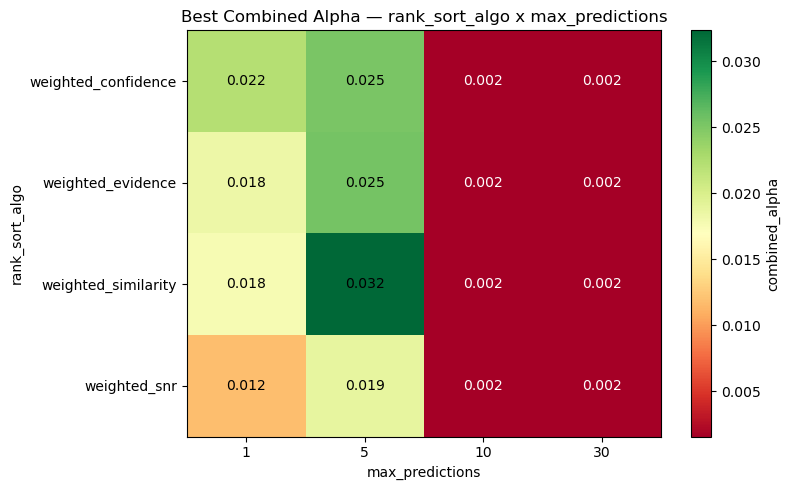

In [18]:
# Heatmap: rank_sort_algo x max_predictions — best combined_alpha per cell
pivot = eval_df.groupby(['rank_sort_algo', 'max_predictions'])['combined_alpha'].max().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([int(c) for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('max_predictions')
ax.set_ylabel('rank_sort_algo')
ax.set_title('Best Combined Alpha — rank_sort_algo x max_predictions')
plt.colorbar(im, label='combined_alpha')

# Annotate cells with values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=10,
                    color='white' if val < pivot.values.mean() else 'black')

plt.tight_layout()
plt.show()

## Churn Probability Distribution

How well-separated are the predicted churn probabilities between actual churners and stayers?

✅ Updated config: {'process_predictions': True, 'rank_sort_algo': 'weighted_similarity', 'max_predictions': 5, 'recall_threshold': 0.1}


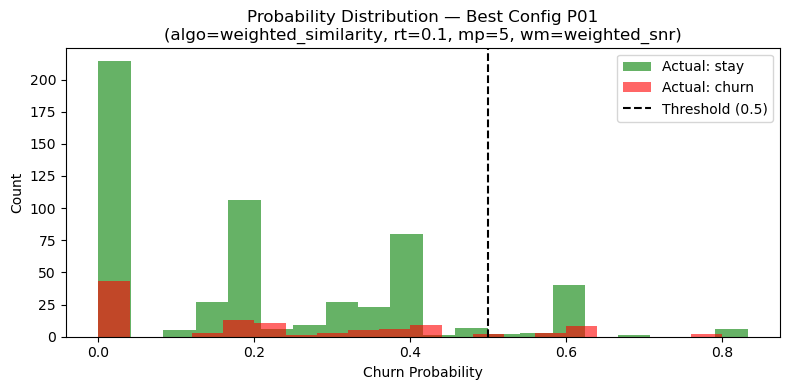

Mean churn prob — actual churners: 0.211
Mean churn prob — actual stayers:  0.203


In [19]:
# Use the best config (P01) for probability distribution analysis
best = eval_df.iloc[0]
best_key = (best["rank_sort_algo"], best["recall_threshold"],
            best["max_predictions"], best["weighting_metric"])
best_predicted = all_classifications[best_key]

# Re-compute probabilities for the best config (need raw predictions for histogram)
# Re-run just the best config to get per-sample probabilities
update_session_config(session_id, {
    "process_predictions": True,
    "rank_sort_algo": best["rank_sort_algo"],
    "max_predictions": int(best["max_predictions"]),
    "recall_threshold": best["recall_threshold"]
})

best_probs = []
for row in churn_test:
    http.post(f"{KATO_URL}/sessions/{session_id}/clear-stm", json={})
    profile_strings = [f"{key}|{value}" for key, value in row.items() if key in feature_columns]
    http.post(f"{KATO_URL}/sessions/{session_id}/observe",
              json={"strings": profile_strings, "vectors": [], "emotives": {}})
    response = http.get(f"{KATO_URL}/sessions/{session_id}/predictions")
    preds = response.json() if response.status_code == 200 else {"predictions": []}
    prob, _, _ = compute_churn_probability(
        preds, weighting_metric=best["weighting_metric"],
        method=PROBABILITY_METHOD, temperature=TEMPERATURE)
    best_probs.append(prob)

results_df = pd.DataFrame({
    "actual": actuals,
    "churn_prob": best_probs,
    "ensemble_pred": best_predicted
})

fig, ax = plt.subplots(figsize=(8, 4))
churn_probs_actual_churn = results_df[results_df['actual'] == 'churn']['churn_prob']
churn_probs_actual_stay = results_df[results_df['actual'] == 'stay']['churn_prob']

ax.hist(churn_probs_actual_stay, bins=20, alpha=0.6, label='Actual: stay', color='green')
ax.hist(churn_probs_actual_churn, bins=20, alpha=0.6, label='Actual: churn', color='red')
ax.axvline(x=CLASSIFICATION_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold ({CLASSIFICATION_THRESHOLD})')
ax.set_xlabel('Churn Probability')
ax.set_ylabel('Count')
ax.set_title(f'Probability Distribution — Best Config {best["label"]}\n'
             f'(algo={best["rank_sort_algo"]}, rt={best["recall_threshold"]}, '
             f'mp={int(best["max_predictions"])}, wm={best["weighting_metric"]})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean churn prob — actual churners: {churn_probs_actual_churn.mean():.3f}")
print(f"Mean churn prob — actual stayers:  {churn_probs_actual_stay.mean():.3f}")

## Symbol Affinity Analysis

Affinity is a per-symbol cumulative sum of emotive values across all patterns containing the symbol.
Symbols with highly positive utility affinity are key indicators of customer **retention** (stay).
Symbols with highly negative utility affinity are key indicators of customer **churn**.
Symbols near zero are **noise** — not contributing to churn/stay classification.

These same affinities drove the weighted similarity calculations in the sweep above. Symbols with high |affinity|/frequency ratios received the highest weights.

In [20]:
# Fetch symbol affinity and stats from KATO
affinity_resp = http.get(f"{KATO_URL}/symbols/affinity", headers={'X-Node-ID': 'churn_ensemble'})
affinity_resp.raise_for_status()
stats_resp = http.get(f"{KATO_URL}/symbols/stats", headers={'X-Node-ID': 'churn_ensemble'})
stats_resp.raise_for_status()

affinities = affinity_resp.json()['affinities']
symbol_stats = stats_resp.json()['symbols']

# Build combined DataFrame
rows = []
for symbol, aff in affinities.items():
    stats = symbol_stats.get(symbol, {})
    rows.append({
        'symbol': symbol,
        'frequency': stats.get('frequency', 0),
        'pmf': stats.get('pattern_member_frequency', 0),
        'utility_affinity': aff.get('utility', 0.0)
    })

affinity_df = pd.DataFrame(rows)
if affinity_df.empty:
    print("\u26a0\ufe0f No affinity data found. Training must complete before running this cell.")
else:
    print(f"Total symbols with affinity data: {len(affinity_df)}")

Total symbols with affinity data: 9059


In [21]:
# Top 10 symbols with highest positive utility affinity — retention indicators
if not affinity_df.empty:
    top_retention = affinity_df.nlargest(10, 'utility_affinity')
    print("\U0001f7e2 Top 10 Retention Indicators (highest positive utility affinity)\n")
    print(top_retention[['symbol', 'frequency', 'pmf', 'utility_affinity']].to_string(index=False))
else:
    print("Skipped — no affinity data available.")

🟢 Top 10 Retention Indicators (highest positive utility affinity)

          symbol  frequency  pmf  utility_affinity
   Int'l Plan|no       2405 2405          187700.0
   VMail Plan|no       1928 1928          131000.0
 VMail Message|0       1928 1928          131000.0
   Area Code|415       1315 1315           95300.0
CustServ Calls|1        959  959           74700.0
  VMail Plan|yes        738  738           60800.0
   Area Code|510        691  691           48900.0
   Area Code|408        660  660           47600.0
CustServ Calls|2        600  600           46600.0
CustServ Calls|0        552  552           41800.0


In [22]:
# Top 10 symbols with most negative utility affinity — churn indicators
if not affinity_df.empty:
    top_churn = affinity_df.nsmallest(10, 'utility_affinity')
    print("\U0001f534 Top 10 Churn Indicators (most negative utility affinity)\n")
    print(top_churn[['symbol', 'frequency', 'pmf', 'utility_affinity']].to_string(index=False))
else:
    print("Skipped — no affinity data available.")

🔴 Top 10 Churn Indicators (most negative utility affinity)

            symbol  frequency  pmf  utility_affinity
  CustServ Calls|5         50   50           -1200.0
  CustServ Calls|6         16   16            -400.0
    Eve Mins|205.7          3    3            -300.0
    Intl Mins|13.9         11   11            -300.0
  Intl Charge|3.75         11   11            -300.0
    Day Mins|167.1          2    2            -200.0
  Eve Charge|20.86          2    2            -200.0
Night Charge|12.81          2    2            -200.0
    Day Mins|239.7          2    2            -200.0
    Day Mins|303.9          2    2            -200.0


In [23]:
# Top 10 symbols closest to zero affinity — noise/non-contributing
if not affinity_df.empty:
    affinity_df['abs_utility'] = affinity_df['utility_affinity'].abs()
    noise = affinity_df.nsmallest(10, 'abs_utility')
    print("\u26aa Top 10 Noise Symbols (utility affinity nearest zero)\n")
    print(noise[['symbol', 'frequency', 'pmf', 'utility_affinity']].to_string(index=False))
else:
    print("Skipped — no affinity data available.")

⚪ Top 10 Noise Symbols (utility affinity nearest zero)

            symbol  frequency  pmf  utility_affinity
  Night Mins|105.4          2    2               0.0
  Day Charge|25.18          2    2               0.0
    Eve Mins|209.4          6    6               0.0
   Eve Charge|14.2          6    6               0.0
    Eve Mins|264.8          2    2               0.0
    Day Mins|265.6          2    2               0.0
  Eve Charge|18.22          2    2               0.0
Night Charge|12.16          2    2               0.0
  Night Mins|193.1          2    2               0.0
    Day Mins|130.5          2    2               0.0


# Interpretation

The symbol affinities tell a compelling story. In this dataset, there is no `Int'l Plan|yes` values, perhaps an oversight of the data gathering or ETL step. However, note that the `Int'l Plan|no` has a high, positive affinity correlating with customers that stay, inferring the opposite for customers with an international plan. Couple that with the first few symbols from the *Top 10 Churn Indicators* (e.g. `CustServ Calls|`, `Eve Mins|` when most international calls are made, `Intl Mins|`, etc.) and we notice that it is likely that customers who have trouble making international calls, reach out to customer service and are still unable to resolve the issues after 5 or 6 `CustServ Calls`. These are the customers that are most likely to churn.

Most of the other symbols (e.g. `Night Mins|`, `Day Charge|`, etc.) do not apply much of a weight to the outcomes. Their influence is should be discounted.

This makes sense because the local phone company has no influence over the foreign telecom services. Customer service can only do so much for the international callers. Those callers, unsatisfied with the service after 5 or 6 complaints end up churning in hopes that a different carrier can provide better international service.

## Weighted indicators

Behind the scenes, KATO is capable of weighting those indicators, appropriately. After doing so, the results of the predictions dramatically improve from the baseline (See **13. Customer Churn — Utility Polarity Prediction** in *kato_tutorial.ipynb*, with the best churn predictor having an alpha of 6% above random, and one point better than the best predictor from *churn_analysis.ipynb*.

## Additional improvements

The above methodology was to show how KATO can take discrete symbols and associate weights to them beyond those used in pattern matching (which is the primary prediction step) by associating emotive context to the data. Clearly, values such as those captured by `Day Mins|`, `Day Charge|`, `Night Mins|`, `Eve Mins|`, etc can be bucketed or vectorized for greater signal and reduced noise.

# Conclusion

### Results Summary

This experiment tested **affinity-weighted pattern matching** — using per-symbol cumulative emotive charge to weight similarity calculations during prediction.

**Key questions answered:**
1. **Did weighted metrics improve over the unweighted baseline?** — Compare the best weighted config's combined alpha against the baseline's best (from `churn_analysis.ipynb`)
2. **Did affinity weighting make ensembles viable?** — Check the ensemble viability analysis above: does `max_predictions > 1` now compete with `max_predictions = 1`?
3. **Which weighted metric performed best?** — Check the heatmap and top-10 rankings

### How Affinity Weighting Works

- During training, KATO unconditionally accumulates per-symbol affinity from the `utility` emotive
- Before predictions, setting `affinity_emotive="utility"` activates weighted matching
- Weight per symbol: `w = |affinity| / frequency + epsilon` — frequency normalization prevents high-frequency symbols from dominating
- Weighted Dice-Sorensen similarity amplifies signal-signal matches and discounts noise-noise matches